In [61]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
# Data load
matches = pd.read_csv('matches.csv')
print("✅ Data Loaded!")
print(matches.shape)

✅ Data Loaded!
(1095, 20)


In [5]:
matches.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [7]:
features = ['venue', 'team1', 'team2', 
            'toss_winner', 'toss_decision']

target = 'winner'

In [8]:
df = matches[matches['winner'] != 'No Result'].copy()


In [9]:
df = df[features + [target]]    

In [12]:
df.head()

,venue,team1,team2,toss_winner,toss_decision,winner
0,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders
1,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings
2,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils
3,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore
4,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders


In [13]:
le = LabelEncoder()

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   venue          1095 non-null   object
 1   team1          1095 non-null   object
 2   team2          1095 non-null   object
 3   toss_winner    1095 non-null   object
 4   toss_decision  1095 non-null   object
 5   winner         1090 non-null   object
dtypes: object(6)
memory usage: 51.5+ KB


In [18]:
df['venue']=le.fit_transform(df['venue'])
df['team1']=le.fit_transform(df['team1'])
df['team2']=le.fit_transform(df['team2'])
df['toss_winner']=le.fit_transform(df['toss_winner'])
df['toss_decision']=le.fit_transform(df['toss_decision'])
df['winner']=le.fit_transform(df['winner'])

In [19]:
df.head(5)

,venue,team1,team2,toss_winner,toss_decision,winner
0,23,16,8,16,1,8
1,40,6,0,0,0,0
2,16,3,13,13,0,3
3,55,10,16,10,0,16
4,14,8,1,1,0,8


In [21]:
X=df[features]
Y=df['winner']

In [51]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [ ]:
Y_train.shape

(274, 5)

In [ ]:
Y_test.shape

(274,)

In [ ]:

X_train.shape


(821, 5)

In [ ]:


X_test.shape

(821,)

In [53]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [54]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(Y_test, y_pred)

In [59]:
print(f"✅ Model Accuracy: {accuracy*100:.2f}%")

✅ Model Accuracy: 43.38%


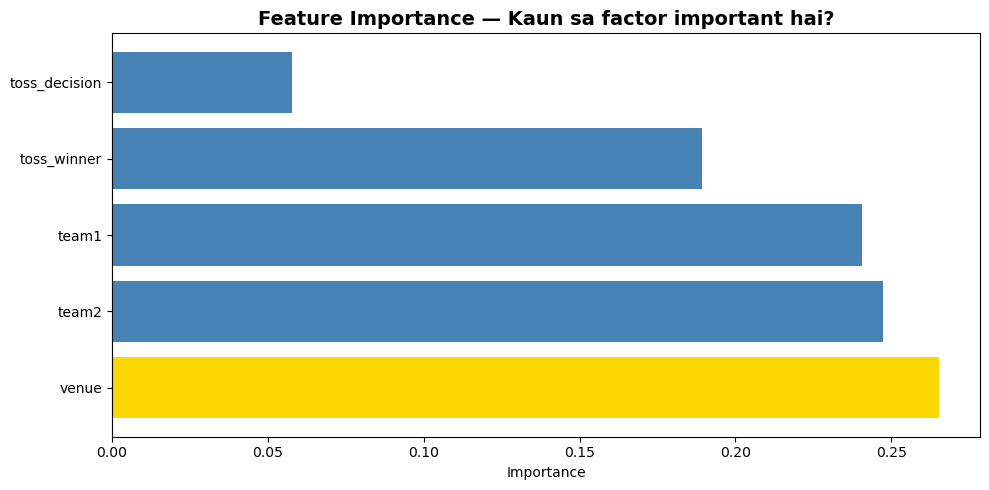

In [62]:
importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['gold' if i == 0 else 'steelblue' 
          for i in range(len(importance))]
ax.barh(importance.index, importance.values, color=colors)
ax.set_title('Feature Importance — Kaun sa factor important hai?',
             fontweight='bold', fontsize=14)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()
